# Dataset Statistics
- Total number of varaints
- single mutants
- double mutants
- unique mutation sites


In [2]:
import numpy as np
import pandas as pd
import sys
sys.path.append(r'C:\Users\Arthur Zhou\GitHub\aps360_project\src')
import os, io, random
import string
import numpy as np
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from Bio.Seq import Seq
from Bio.Align import MultipleSeqAlignment
from Bio import AlignIO, SeqIO
from Bio.SeqRecord import SeqRecord


from data.data_utils import load_data, compare_single_fitness, load_cif_structure, parse_structure
from data.feature_utils import align_sequence

### Single 
Data loaded. Prior size: 5741, After dropna: 5483
### Double 
Data loaded. Prior size: 12374, After dropna: 12374

In [3]:
dms = pd.read_csv(r'C:\Users\Arthur Zhou\GitHub\aps360_project\src\data\processed\both\dms_processed.csv')

In [4]:
n_variants = dms['Code'].nunique()
n_single = dms[dms['Single'] == 1]['Code'].nunique()
n_pair = dms[dms['Single'] == 0]['Code'].nunique()
n_mut_sites = dms['Ambler Index'].nunique()
print(f"Number of variants: {n_variants}")
print(f"Number of single mutants: {n_single}")
print(f"Number of pair mutants: {n_pair}")
print(f"Number of unique mutation sites: {n_mut_sites}")

Number of variants: 17857
Number of single mutants: 5483
Number of pair mutants: 12374
Number of unique mutation sites: 287


### sequence alignment

In [5]:
pdb_seq, _ = parse_structure(load_cif_structure(r'C:\Users\Arthur Zhou\GitHub\aps360_project\src\data\processed\1BTL.cif', "1BTL"))
single_seq = dms.loc[dms['Single'] == 1]['Experiment Sequence'].iloc[0]
pair_seq = dms.loc[dms['Single'] == 0]['Experiment Sequence'].iloc[0]

s_map, s_p =align_sequence(single_seq, pdb_seq)
p_map, p_p =align_sequence(pair_seq, pdb_seq)


print("single pdb sequence:")
print(len(s_map.keys())) 
print("pair pdb sequence:")
print(len(p_map.keys()))

final_single = dms[dms['Single'] == 1][dms['Ambler Index'].isin(s_map.keys())]
final_pair = dms[dms['Single'] == 0][dms['Ambler Index'].isin(p_map.keys())]

final_dms = pd.concat([final_single, final_pair])

n_final_s_variants = final_single['Code'].nunique()
n_final_p_variants = final_pair['Code'].nunique()
n_total_variants = pd.concat([final_single, final_pair])['Code'].nunique()
n_mut_sites_final = pd.concat([final_single, final_pair])['Ambler Index'].nunique()

print(f"Number of unique total variants: {n_total_variants}")
print(f"Number of unique single variants: {n_final_s_variants}")
print(f"Number of unique pair variants: {n_final_p_variants}")
print(f"Number of unique mutation sites in final dataset: {n_mut_sites_final}")

single pdb sequence:
263
pair pdb sequence:
258
Number of unique total variants: 16586
Number of unique single variants: 5032
Number of unique pair variants: 11554
Number of unique mutation sites in final dataset: 263


C:\Users\Arthur Zhou\AppData\Local\Temp\ipykernel_36724\4265109181.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  final_single = dms[dms['Single'] == 1][dms['Ambler Index'].isin(s_map.keys())]
C:\Users\Arthur Zhou\AppData\Local\Temp\ipykernel_36724\4265109181.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  final_pair = dms[dms['Single'] == 0][dms['Ambler Index'].isin(p_map.keys())]


In [6]:
from PIL import Image, ImageDraw, ImageFont

def plot_sequences_image(
    p_target,
    p_q,
    title="Sequence Alignment",
    cell_w=10,
    cell_h=10,
    max_cols=120
):

    assert len(p_target) == len(p_q)
    L = len(p_target)

    try:
        font = ImageFont.truetype("DejaVuSansMono.ttf", 9)
    except:
        font = ImageFont.load_default()

    n_blocks = (L + max_cols - 1) // max_cols
    images = []

    for r in range(n_blocks):

        start = r * max_cols
        end = min((r + 1) * max_cols, L)
        ncols = end - start

        width = ncols * cell_w + 120
        height = 3 * cell_h + 20

        img = Image.new("RGB", (width, height), "white")
        draw = ImageDraw.Draw(img)

        def cell(x, y, char, color):
            x0 = 110 + (x - start) * cell_w
            y0 = 14 + y * cell_h

            draw.rectangle(
                [x0, y0, x0 + cell_w, y0 + cell_h],
                fill=color,
                outline="#e6e6e6"
            )

            draw.text((x0 + 2, y0), char, fill="black", font=font)

        # labels
        draw.text((5, 18), "Experiment", fill="black", font=font)
        draw.text((5, 18 + cell_h), "PDB", fill="black", font=font)
        draw.text((5, 18 + 2 * cell_h), "", fill="black", font=font)

        for i in range(start, end):

            t, q = p_target[i], p_q[i]

            if t == "-" or q == "-":
                ct = cq = "#d9d9d9"
            elif t != q:
                ct = "#ffcccc"
                cq = "#ff6b6b"
            else:
                ct = cq = "white"

            cell(i, 0, t, ct)
            cell(i, 1, q, cq)

            if i % 10 == 0:
                x0 = 110 + (i - start) * cell_w + 1
                y0 = 14 + 2 * cell_h + 2
                draw.text((x0, y0), str(i), fill="#444444", font=font)

        images.append(img)

    # stack blocks
    total_h = sum(im.height for im in images)

    final = Image.new("RGB", (images[0].width, total_h + 30), "white")
    draw_final = ImageDraw.Draw(final)

    # -----------------------------
    # SINGLE CENTERED TITLE
    # -----------------------------
    title_w = draw_final.textlength(title, font=font)
    draw_final.text(
        ((final.width - title_w) / 2, 5),
        title,
        fill="black",
        font=font
    )

    y = 25
    for im in images:
        final.paste(im, (0, y))
        y += im.height

    return final

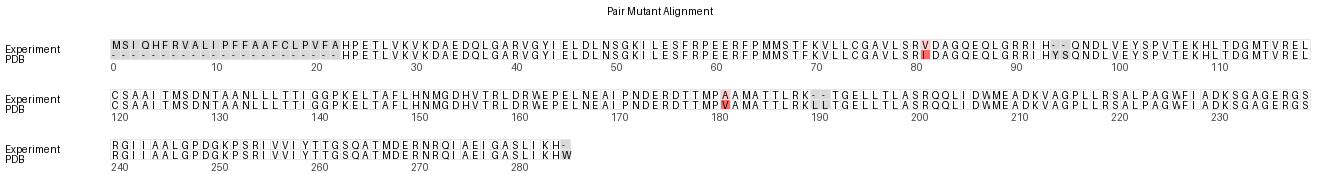

In [7]:
p_target = "MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRVDAGQEQLGRRIH--QNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDHVTRLDRWEPELNEAIPNDERDTTMPAAMATTLRK--TGELLTLASRQQLIDWMEADKVAGPLLRSALPAGWFIADKSGAGERGSRGIIAALGPDGKPSRIVVIYTTGSQATMDERNRQIAEIGASLIKH-"
p_mid = "-----------------------||||||||||||||||||||||||||||||||||||||||||||||||||||||||||.||||||||||||--|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||.||||||||--|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||-"
p_q = "-----------------------HPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRIDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDHVTRLDRWEPELNEAIPNDERDTTMPVAMATTLRKLLTGELLTLASRQQLIDWMEADKVAGPLLRSALPAGWFIADKSGAGERGSRGIIAALGPDGKPSRIVVIYTTGSQATMDERNRQIAEIGASLIKHW"


s_target="MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRVDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDHVTRLDRWEPELNEAIPNDERDTTMPAAMATTLRKLLTGELLTLASRQQLIDWMEADKVAGPLLRSALPAGWFIADKSGAGERGSRGIIAALGPDGKPSRIVVIYTTGSQATMDERNRQIAEIGASLIKHW*"
s_q = "-----------------------HPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRIDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDHVTRLDRWEPELNEAIPNDERDTTMPVAMATTLRKLLTGELLTLASRQQLIDWMEADKVAGPLLRSALPAGWFIADKSGAGERGSRGIIAALGPDGKPSRIVVIYTTGSQATMDERNRQIAEIGASLIKHW-"
plot_sequences_image(p_target, p_q, title="Pair Mutant Alignment")



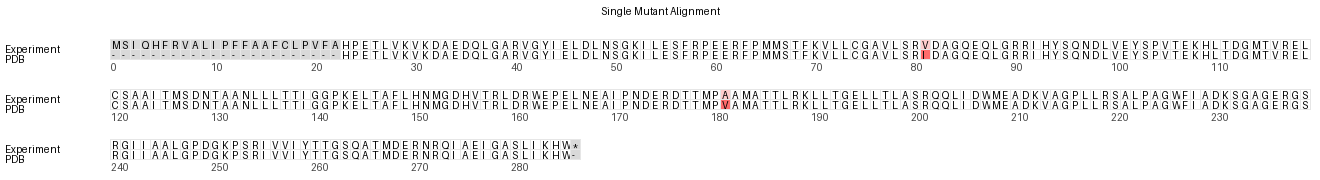

In [197]:

plot_sequences_image(s_target, s_q, title="Single Mutant Alignment")

### distribution of mutations

In [206]:
import pandas as pd

def extract_all_mutations(df, col):

    records = []

    for val in df[col].dropna():

        parts = val.split("_")

        try:

            # -------------------------
            # SINGLE MUTATION
            # aa_pos_mut
            # -------------------------
            if len(parts) == 3:
                _, pos, mut = parts
                records.append((int(pos), mut))

            # -------------------------
            # DOUBLE MUTATION (6 fields)
            # aa1_aa2_pos1_pos2_mut1_mut2
            # -------------------------
            elif len(parts) == 6:
                _, _, pos1, pos2, mut1, mut2 = parts
                records.append((int(pos1), mut1))
                records.append((int(pos2), mut2))

            # -------------------------
            # DOUBLE MUTATION (5 fields)
            # H_P_26_F_L  (your case)
            # -------------------------
            elif len(parts) == 5:
                _, _, pos, mut1, mut2 = parts
                records.append((int(pos), mut1))
                records.append((int(pos), mut2))

            else:
                raise ValueError(f"Unknown format: {val}")

        except Exception as e:
            print(f"Skipping bad entry: {val} -> {e}")

    return pd.DataFrame(records, columns=["pos", "mut"])

AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def build_mut_matrix(muts_df):

    max_pos = muts_df["pos"].max() + 1

    mat = np.zeros((len(AMINO_ACIDS), max_pos), dtype=int)

    aa_to_i = {aa:i for i, aa in enumerate(AMINO_ACIDS)}

    for _, row in muts_df.iterrows():
        aa = row["mut"]
        pos = row["pos"]

        if aa in aa_to_i:
            mat[aa_to_i[aa], pos] += 1

    return mat, max_pos
    
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def plot_mutation_heatmap(mat):

    mat_log = np.log10(mat + 1)

    total_row = np.log10(mat.sum(axis=0) + 1).reshape(1, -1)

    mat_aug = np.vstack([mat_log, total_row])

    # y-axis labels (20 AA + Total row)
    y_labels = AMINO_ACIDS + ["Total"]

    plt.figure(figsize=(16, 3.5), dpi=400)

    ax = sns.heatmap(
        mat_aug,
        cmap="mako",
        xticklabels=10,
        yticklabels=y_labels,
        linewidths=0.03,
        linecolor="gray",
        cbar_kws={"label": "log10(count+1)", "pad": 0.02}
    )

    ax.set_xlabel("Ambler Position")
    ax.set_ylabel("Amino acid")

    ax.set_title("Mutation Landscape")

    plt.tight_layout()
    plt.show()

In [49]:
temp = extract_all_mutations(final_dms, "Code")
mat, max_pos = build_mut_matrix(temp)

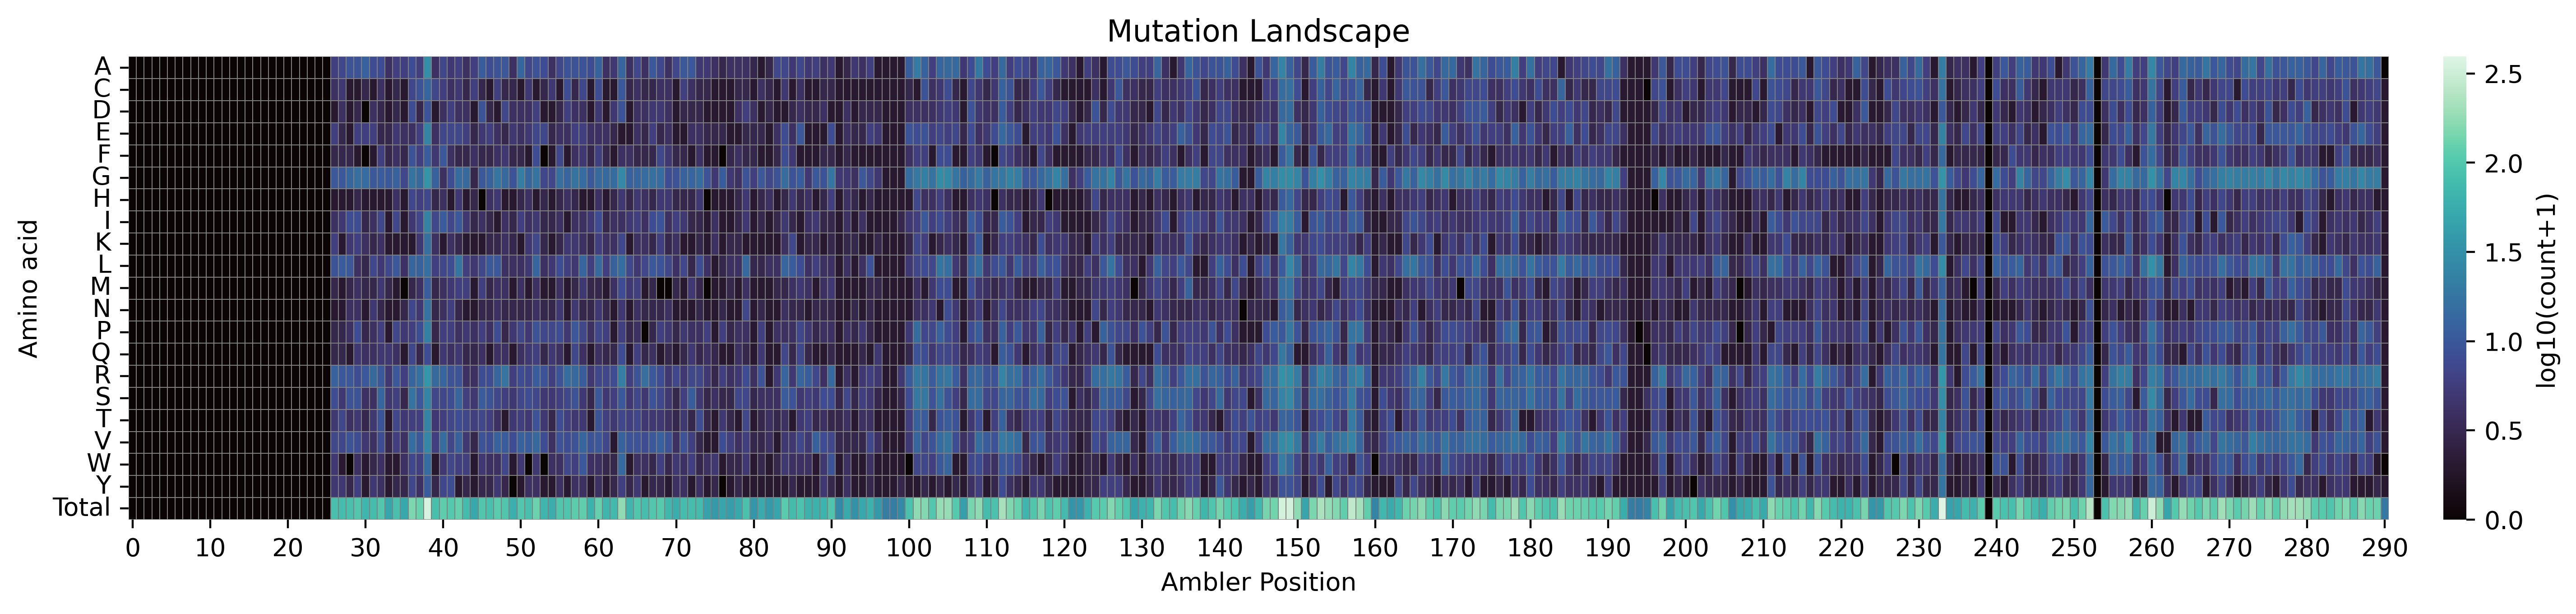

In [207]:
plot_mutation_heatmap(mat)

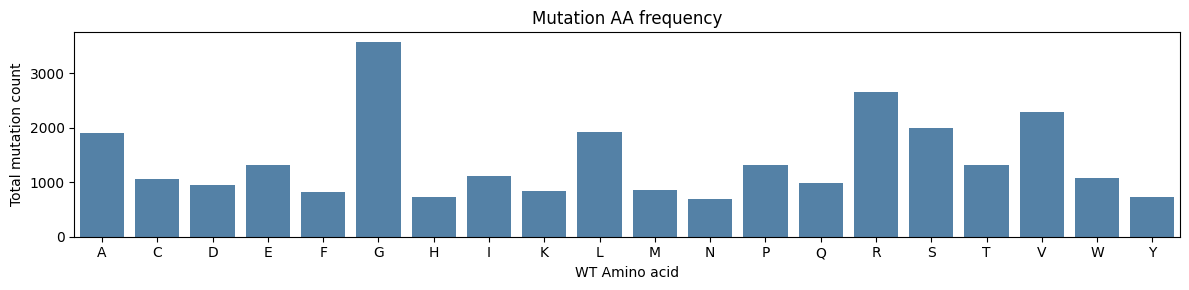

In [211]:
import numpy as np
import matplotlib.pyplot as plt

AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")


def plot_aa_mutation_hist(mat):

    counts = mat.sum(axis=1)

    df_plot = pd.DataFrame({
        "Amino Acid": AMINO_ACIDS,
        "Count": counts
    })
    plt.figure(figsize=(12, 3))

    sns.barplot(
        data=df_plot,
        x="Amino Acid",
        y="Count",
        color="steelblue"
    )
    plt.xlabel("WT Amino acid")
    plt.ylabel("Total mutation count")
    plt.title("Mutation AA frequency")

    plt.tight_layout()
    plt.show()

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt




plot_aa_mutation_hist(mat)

### aa index data

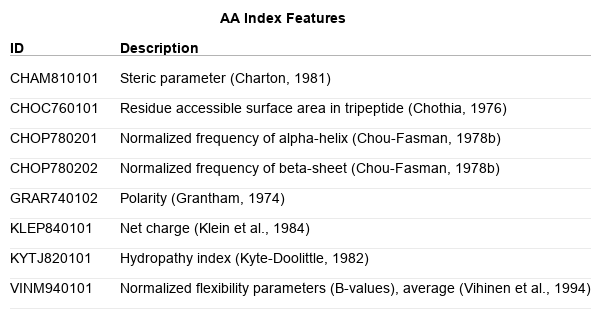

In [184]:
aa = pd.read_csv(r'C:\Users\Arthur Zhou\GitHub\aps360_project\src\data\processed\aa_index_data.csv')

from PIL import Image, ImageDraw, ImageFont
from PIL import Image, ImageDraw, ImageFont

def plot_aa(ids, descriptions):

    # --- compact layout settings ---
    row_height = 30
    left_pad = 10
    col1_x = 10
    col2_x = 120
    top_pad = 10

    width = 600
    height = row_height * (len(ids) + 3)

    img = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)

    # font (smaller, compact)
    try:
        font = ImageFont.truetype("arial.ttf", 14)
        font_bold = ImageFont.truetype("arialbd.ttf", 14)
    except:
        font = ImageFont.load_default()
        font_bold = ImageFont.load_default()

    y = top_pad

    # title (small, centered-ish)
    draw.text((width // 2 - 80, y), "AA Index Features", fill="black", font=font_bold)
    y += row_height

    # header line
    draw.text((col1_x, y), "ID", fill="black", font=font_bold)
    draw.text((col2_x, y), "Description", fill="black", font=font_bold)
    y += row_height // 2

    # thin separator
    draw.line([(col1_x, y), (width - 10, y)], fill=(180, 180, 180), width=1)
    y += row_height // 2

    # rows
    for i, d in zip(ids, descriptions):

        # light row separator (VERY subtle grid)
        draw.line([(col1_x, y + row_height - 2),
                   (width - 10, y + row_height - 2)],
                  fill=(235, 235, 235), width=1)

        draw.text((col1_x, y), str(i), fill="black", font=font)
        draw.text((col2_x, y), str(d), fill="black", font=font)

        y += row_height

    return img

plot_aa(aa['id'], aa['description'])

### Clean training sampoe

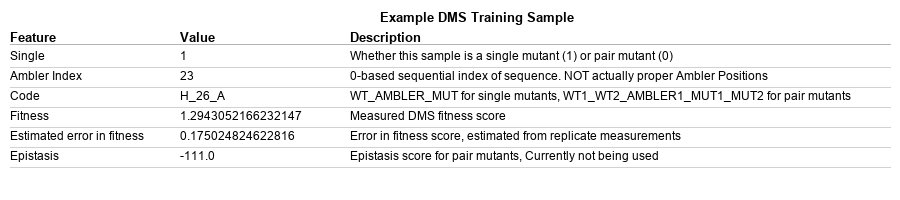

In [196]:
from PIL import Image, ImageDraw, ImageFont

def display_row(row, descriptions=None):

    items = list(row.items())

    row_height = 20
    left_x = 10
    col2_x = 180
    col3_x = 350

    try:
        font = ImageFont.truetype("arial.ttf", 12)
        font_bold = ImageFont.truetype("arialbd.ttf", 13)
    except:
        font = ImageFont.load_default()
        font_bold = ImageFont.load_default()

    width = 900
    height = row_height * (len(items) + 4)

    img = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)

    y = 10

    # title
    draw.text((width // 2 - 70, y), "Example DMS Training Sample", font=font_bold, fill="black")
    y += row_height

    # headers
    draw.text((left_x, y), "Feature", font=font_bold, fill="black")
    draw.text((col2_x, y), "Value", font=font_bold, fill="black")
    draw.text((col3_x, y), "Description", font=font_bold, fill="black")
    y += 14

    # header line
    draw.line([(left_x, y), (width - 10, y)], fill=(180, 180, 180), width=1)
    y += 5

    # rows
    for k, v in items:

        desc = descriptions.get(k, "") if descriptions else ""

        draw.text((left_x, y), str(k), font=font, fill="black")
        draw.text((col2_x, y), str(v), font=font, fill="black")
        draw.text((col3_x, y), str(desc), font=font, fill="black")

        # 🔥 horizontal row separator
        draw.line(
            [(left_x, y + row_height - 2), (width - 10, y + row_height - 2)],
            fill=(210, 210, 210),
            width=1
        )

        y += row_height

    return img
temp_sample = final_dms.iloc[0, :-1].copy()
temp_pair = final_dms.iloc[1000, :-1].copy()
descriptions = {
    "Single": "Whether this sample is a single mutant (1) or pair mutant (0)",
    "Ambler Index": "0-based sequential index of sequence. NOT actually proper Ambler Positions",
    "Code": "WT_AMBLER_MUT for single mutants, WT1_WT2_AMBLER1_MUT1_MUT2 for pair mutants",
    "Fitness": "Measured DMS fitness score",
    "Estimated error in fitness": "Error in fitness score, estimated from replicate measurements",
    "Epistasis": "Epistasis score for pair mutants, Currently not being used", 
}

display_row(temp_sample, descriptions)


In [151]:
def display_row_styled(df, idx=0):

    return (
        df.iloc[[idx]]
        .style
        .set_properties(**{
            "text-align": "left"
        })
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "left")]}
        ])
        .background_gradient(axis=1)
    )
display_row_styled(final_dms, idx=0)

,Single,Ambler Index,Code,Fitness,Estimated error in fitness,Epistasis,Experiment Sequence
437,1,23,H_26_A,1.294305,0.175025,-111.000000,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRVDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDHVTRLDRWEPELNEAIPNDERDTTMPAAMATTLRKLLTGELLTLASRQQLIDWMEADKVAGPLLRSALPAGWFIADKSGAGERGSRGIIAALGPDGKPSRIVVIYTTGSQATMDERNRQIAEIGASLIKHW*


### pdb backbone